# Assignment 10


## Imports


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons


## Task 1 — Train a simple VAE on MNIST or Fashion-MNIST (3 pts)

In this task, you will train a simple **Variational Autoencoder**.

A VAE encoder does not produce one fixed latent vector. Instead, it produces the parameters of a Gaussian distribution:

$$
q_\phi(z \mid x)
=
\mathcal{N}(\mu_\phi(x), \operatorname{diag}(\sigma_\phi^2(x))).
$$

Then a latent vector is sampled using the reparameterization trick:

$$
z = \mu + \sigma \odot \epsilon,
\qquad
\epsilon \sim \mathcal{N}(0,I).
$$

The decoder maps the latent vector back to an image:

$$
z \rightarrow \hat{x}.
$$

After training, new images can be generated by sampling:

$$
z \sim \mathcal{N}(0,I)
$$

and passing $z$ through the decoder.

---

## Dataset

Use either **MNIST** or **Fashion-MNIST**.

Each image has shape:

$$
x \in \mathbb{R}^{1 \times 28 \times 28}.
$$

For a fully connected VAE, flatten the image:

$$
x \in \mathbb{R}^{784}.
$$

Use pixel values in the range $[0,1]$.

---

## Model

Use a simple fully connected VAE.

A suggested architecture is:

```
encoder:
784 -> 400 -> mu
          -> logvar

latent dimension:
z_dim = 2, 10, or 20

decoder:
z_dim -> 400 -> 784
```

The decoder should output logits.

---

## VAE loss

$$
\mathcal{L}(x)
=
\mathcal{L}_{reconstruction}(x)
+
\mathcal{L}_{KL}(x).
$$

Reconstruction term (binary cross-entropy):

$$
\mathcal{L}_{reconstruction}
=
-
\sum_{j=1}^{784}
\left[
x_j \log \hat{x}_j + (1-x_j)\log(1-\hat{x}_j)
\right].
$$

KL term:

$$
D_{KL}(q_\phi(z \mid x) \| p(z))
=
-\frac{1}{2}
\sum_{j=1}^{d}
\left(
1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2
\right).
$$

---

## Requirements

1. Load MNIST or Fashion-MNIST using TorchVision.
2. Implement a fully connected VAE with encoder, mu/logvar layers, reparameterization, and decoder.
3. Train for at least 3 epochs.
4. Use binary cross-entropy reconstruction loss, KL divergence loss, and an optimizer from `torch.optim`.
5. Plot total training loss, reconstruction loss, and KL loss.
6. Show at least 8 reconstructions (original and reconstructed).
7. Generate at least 16 new images by sampling $z \sim \mathcal{N}(0,I)$.
8. Try `z_dim = 20`. Optional: also try `z_dim = 2` and compare.

---

## Required discussion

Explain:
- what the encoder outputs,
- why the encoder outputs `mu` and `logvar`,
- why the reparameterization trick is needed,
- what the KL term encourages,
- why generated samples are obtained from $z \sim \mathcal{N}(0,I)$,
- whether the generated samples are sharp, blurry, or unclear,
- optional: what changes when the latent dimension is small or large.


### Solution


In [2]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


100%|██████████| 9.91M/9.91M [00:01<00:00, 8.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 223kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 19.4MB/s]


In [3]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps
        return z

    def decode(self, z):
        logits = self.decoder(z)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


In [4]:
def vae_loss(x_logits, x, mu, logvar):
    batch_size = x.size(0)
    reconstruction_loss = F.binary_cross_entropy_with_logits(
        x_logits, x, reduction='sum'
    ) / batch_size
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
    loss = reconstruction_loss + kl_loss
    return loss, reconstruction_loss, kl_loss


In [5]:
latent_dim = 20
model_vae = VAE(latent_dim=latent_dim).to(device)
optimizer_vae = optim.Adam(model_vae.parameters(), lr=1e-3)

epochs = 10
total_losses, recon_losses, kl_losses = [], [], []

for epoch in range(epochs):
    model_vae.train()
    epoch_total, epoch_recon, epoch_kl = 0.0, 0.0, 0.0
    n_batches = 0
    for x, _ in train_loader:
        x = x.view(x.size(0), -1).to(device)
        optimizer_vae.zero_grad()
        x_logits, mu, logvar = model_vae(x)
        loss, recon_loss, kl_loss = vae_loss(x_logits, x, mu, logvar)
        loss.backward()
        optimizer_vae.step()
        epoch_total += loss.item()
        epoch_recon += recon_loss.item()
        epoch_kl += kl_loss.item()
        n_batches += 1
    total_losses.append(epoch_total / n_batches)
    recon_losses.append(epoch_recon / n_batches)
    kl_losses.append(epoch_kl / n_batches)
    print(f'Epoch {epoch+1}/{epochs} | total: {total_losses[-1]:.2f} | recon: {recon_losses[-1]:.2f} | KL: {kl_losses[-1]:.2f}')


Epoch 1/10 | total: 163.40 | recon: 147.46 | KL: 15.94
Epoch 2/10 | total: 121.10 | recon: 98.38 | KL: 22.72
Epoch 3/10 | total: 114.54 | recon: 90.35 | KL: 24.19
Epoch 4/10 | total: 111.54 | recon: 86.90 | KL: 24.64
Epoch 5/10 | total: 109.79 | recon: 84.89 | KL: 24.90
Epoch 6/10 | total: 108.68 | recon: 83.62 | KL: 25.06
Epoch 7/10 | total: 107.77 | recon: 82.60 | KL: 25.17
Epoch 8/10 | total: 107.05 | recon: 81.84 | KL: 25.21
Epoch 9/10 | total: 106.56 | recon: 81.25 | KL: 25.30
Epoch 10/10 | total: 106.09 | recon: 80.75 | KL: 25.34


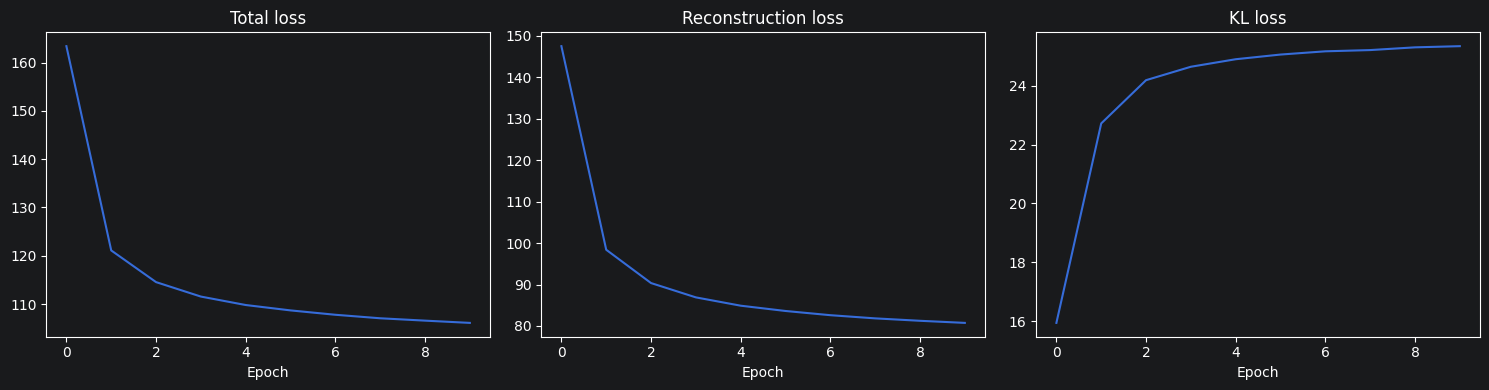

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(total_losses)
axes[0].set_title('Total loss')
axes[0].set_xlabel('Epoch')
axes[1].plot(recon_losses)
axes[1].set_title('Reconstruction loss')
axes[1].set_xlabel('Epoch')
axes[2].plot(kl_losses)
axes[2].set_title('KL loss')
axes[2].set_xlabel('Epoch')
plt.tight_layout()
plt.show()


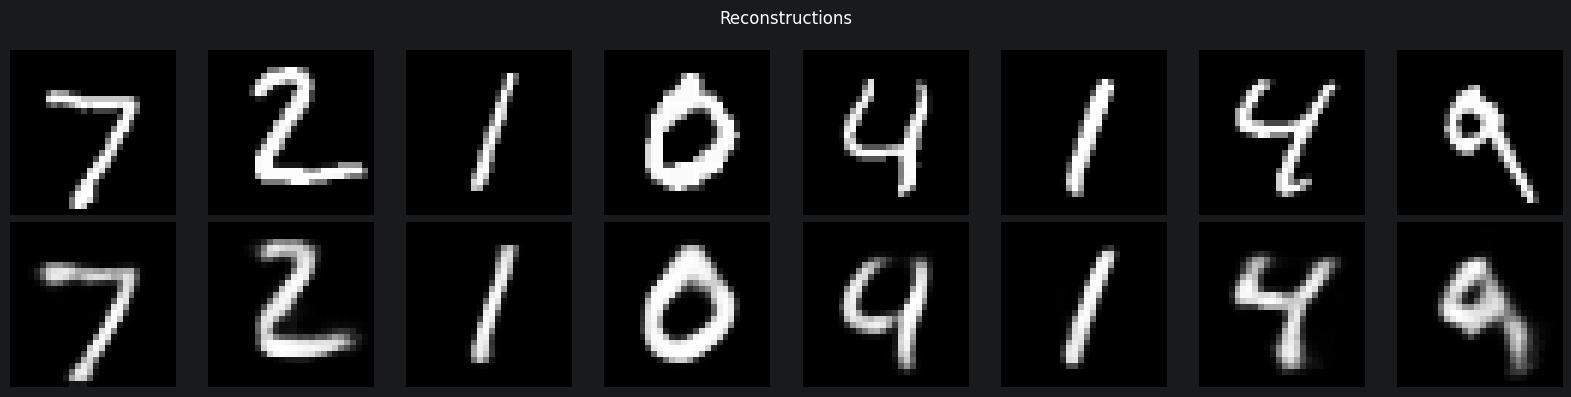

In [7]:
model_vae.eval()
x_batch, _ = next(iter(test_loader))
x_batch = x_batch[:8].to(device)
x_flat = x_batch.view(x_batch.size(0), -1)
with torch.no_grad():
    x_logits, _, _ = model_vae(x_flat)
    x_recon = torch.sigmoid(x_logits).view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(x_batch[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_recon[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original')
axes[1, 0].set_ylabel('Reconstructed')
plt.suptitle('Reconstructions')
plt.tight_layout()
plt.show()


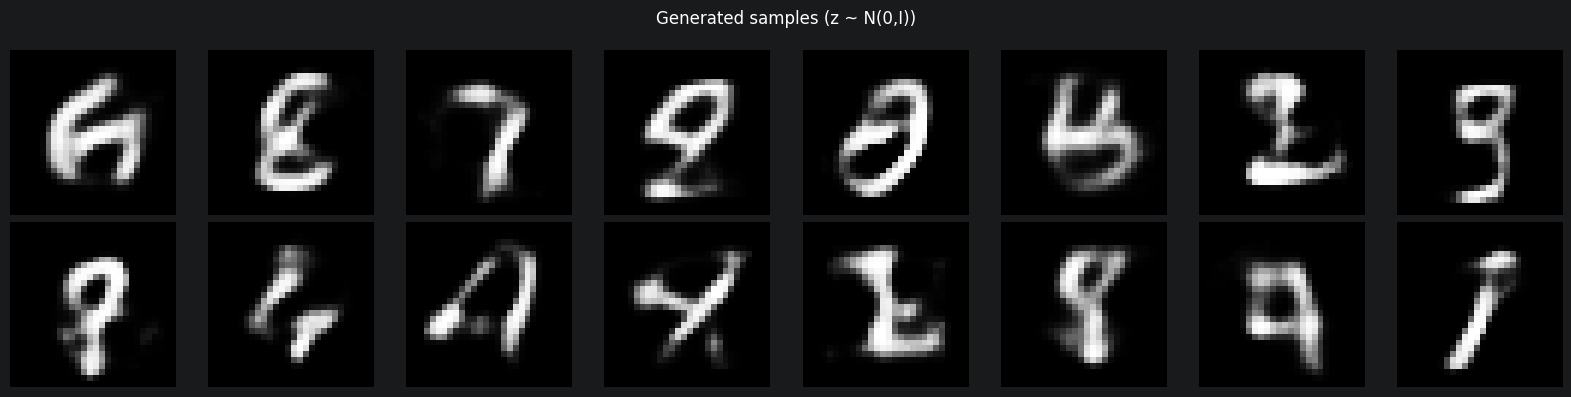

In [8]:
model_vae.eval()
with torch.no_grad():
    z_sample = torch.randn(16, latent_dim).to(device)
    x_gen = torch.sigmoid(model_vae.decode(z_sample)).view(-1, 1, 28, 28)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    axes[i // 8, i % 8].imshow(x_gen[i].cpu().squeeze(), cmap='gray')
    axes[i // 8, i % 8].axis('off')
plt.suptitle('Generated samples (z ~ N(0,I))')
plt.tight_layout()
plt.show()


### Discussion

- **What the encoder outputs:** The encoder outputs two vectors, `mu` and `logvar`, which are the mean and log-variance of a Gaussian distribution over the latent space.

- **Why `mu` and `logvar`:** Instead of a single point in latent space, the encoder defines a distribution so the model can learn a smooth, continuous latent space that generalises well.

- **Why the reparameterization trick is needed:** Direct sampling from a stochastic node blocks gradient flow; the trick writes `z = mu + sigma * eps` (eps ~ N(0,I)) so gradients can flow through `mu` and `logvar` during backpropagation.

- **What the KL term encourages:** The KL term pushes the encoder distribution toward the standard normal prior N(0,I), preventing the model from ignoring the prior and ensuring the latent space is well-structured for sampling.

- **Why generated samples come from N(0,I):** Because the KL term trains the encoder to match this prior, sampling from it gives points in a region the decoder has learned to decode meaningfully.

- **Sharpness of generated samples:** VAE-generated samples tend to be slightly blurry because the reconstruction loss averages over the distribution, but on MNIST they are generally recognisable.


## Task 2 — Flow matching on a 2D toy dataset (3 pts)

In this task, you will train a small neural network to learn a velocity field that transports samples from a simple noise distribution to a data distribution.

This is a simplified version of the idea behind flow matching.

Instead of generating images, we generate 2D points.

---

## Dataset

Use a simple 2D dataset such as two moons, circles, a spiral, or a mixture of Gaussians.

The noise point is sampled from a standard normal distribution:

$$
x_0 \sim \mathcal{N}(0,I).
$$

---

## Linear interpolation path

For a time value $t \in [0,1]$, define the interpolation between noise and data:

$$
x_t = (1-t)x_0 + t x_1.
$$

The target velocity for this simple path is:

$$
u_t = x_1 - x_0.
$$

A neural network learns:

$$
v_\theta(x_t,t) \approx u_t.
$$

The training loss is:

$$
\mathcal{L}_{FM}
=
\left\|v_\theta(x_t,t) - (x_1-x_0)\right\|_2^2.
$$

---

## Model

Use a small MLP with input dimension 3 ($[x_{t,1}, x_{t,2}, t]$) and output dimension 2.

Suggested architecture: `3 -> 64 -> 64 -> 64 -> 2`

---

## Requirements

1. Generate or load a 2D toy dataset.
2. Plot the real data distribution.
3. Implement a small MLP that predicts velocity.
4. During training, sample real data points $x_1$, noise points $x_0$, and random times $t \sim U(0,1)$.
5. Construct $x_t = (1-t)x_0 + t x_1$.
6. Train the model to predict $x_1 - x_0$.
7. Plot training loss.
8. Generate new samples by starting from Gaussian noise and integrating the learned velocity field.
9. Plot initial noise points, generated points, and real data points.
10. Try at least two numbers of sampling steps (e.g. 10 and 50) and compare quality.

---

## Sampling

Start from $x_0 \sim \mathcal{N}(0,I)$ and solve the ODE with Euler method:

$$
x_{t+\Delta t} = x_t + \Delta t \cdot v_\theta(x_t,t).
$$

---

## Required discussion

Explain:
- what the model input is,
- what the model output is,
- why the target velocity is $x_1-x_0$ for the linear path,
- why sampling requires multiple small steps,
- what happens when the number of sampling steps is too small,
- how this task is related to diffusion generative models.


### Solution


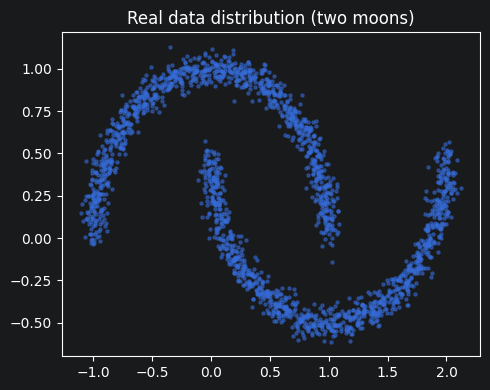

In [9]:
torch.manual_seed(42)
np.random.seed(42)

X_data, _ = make_moons(n_samples=2000, noise=0.05)
X_data = X_data.astype(np.float32)

plt.figure(figsize=(5, 4))
plt.scatter(X_data[:, 0], X_data[:, 1], s=5, alpha=0.5)
plt.title('Real data distribution (two moons)')
plt.tight_layout()
plt.show()


In [10]:
class VelocityNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x_t, t):
        inp = torch.cat([x_t, t], dim=1)
        v = self.net(inp)
        return v


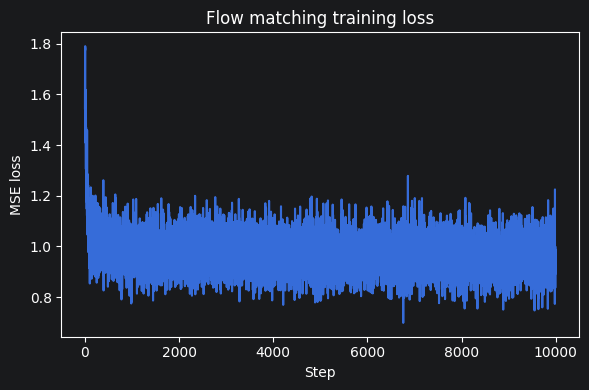

In [11]:
device_fm = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

X_tensor = torch.tensor(X_data).to(device_fm)

vel_net = VelocityNet().to(device_fm)
optimizer_fm = optim.Adam(vel_net.parameters(), lr=1e-3)

n_steps_train = 10000
batch_size_fm = 256
fm_losses = []

vel_net.train()
for step in range(n_steps_train):
    idx = torch.randint(0, X_tensor.size(0), (batch_size_fm,))
    x1 = X_tensor[idx]
    x0 = torch.randn_like(x1)
    t = torch.rand(batch_size_fm, 1, device=device_fm)
    x_t = (1 - t) * x0 + t * x1
    target_velocity = x1 - x0
    predicted_velocity = vel_net(x_t, t)
    loss = F.mse_loss(predicted_velocity, target_velocity)
    optimizer_fm.zero_grad()
    loss.backward()
    optimizer_fm.step()
    fm_losses.append(loss.item())

plt.figure(figsize=(6, 4))
plt.plot(fm_losses)
plt.title('Flow matching training loss')
plt.xlabel('Step')
plt.ylabel('MSE loss')
plt.tight_layout()
plt.show()


In [12]:
@torch.no_grad()
def sample_flow(model, n_samples=1000, n_steps=50, device='cpu'):
    model.eval()
    x = torch.randn(n_samples, 2, device=device)
    dt = 1.0 / n_steps
    for step in range(n_steps):
        t_value = step * dt
        t = torch.full((n_samples, 1), t_value, device=device)
        v = model(x, t)
        x = x + dt * v
    return x


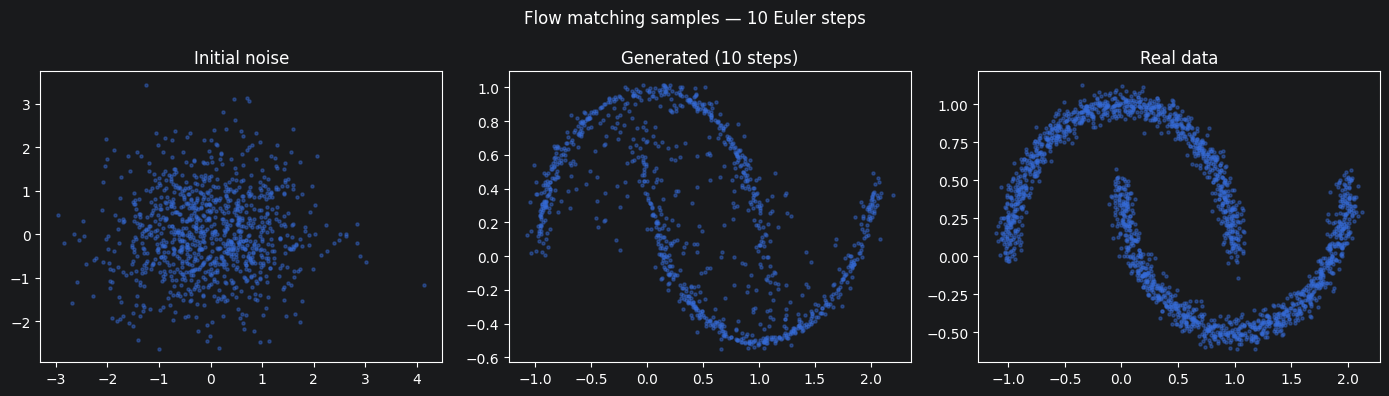

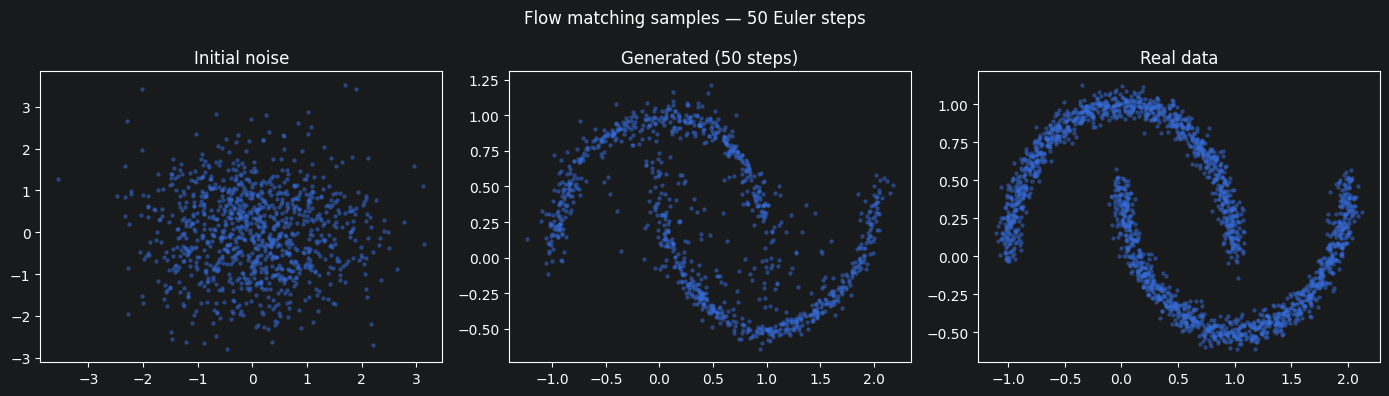

In [13]:
for n_steps in [10, 50]:
    x_init = torch.randn(1000, 2, device=device_fm)
    x_gen = sample_flow(vel_net, n_samples=1000, n_steps=n_steps, device=device_fm).cpu().numpy()
    x_init_np = x_init.cpu().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].scatter(x_init_np[:, 0], x_init_np[:, 1], s=5, alpha=0.4)
    axes[0].set_title('Initial noise')
    axes[1].scatter(x_gen[:, 0], x_gen[:, 1], s=5, alpha=0.4)
    axes[1].set_title(f'Generated ({n_steps} steps)')
    axes[2].scatter(X_data[:, 0], X_data[:, 1], s=5, alpha=0.4)
    axes[2].set_title('Real data')
    plt.suptitle(f'Flow matching samples — {n_steps} Euler steps')
    plt.tight_layout()
    plt.show()


In [14]:
rows = []
for n_steps in [10, 50]:
    x_gen = sample_flow(vel_net, n_samples=1000, n_steps=n_steps, device=device_fm).cpu().numpy()
    rows.append({'Number of steps': n_steps, 'Note': 'coarser' if n_steps == 10 else 'finer'})

pd.DataFrame(rows)


,Number of steps,Note
0,10,coarser
1,50,finer


### Discussion

- **Model input:** A 3-dimensional vector $[x_{t,1}, x_{t,2}, t]$ — the current 2D position along the interpolation path and the current time.

- **Model output:** A 2D velocity vector $v_\theta(x_t, t)$ indicating the direction and speed the point should move at that time.

- **Why the target velocity is $x_1 - x_0$:** For the linear interpolation path $x_t = (1-t)x_0 + t x_1$, differentiating with respect to $t$ gives $\dot{x}_t = x_1 - x_0$, which is constant along the path.

- **Why sampling requires multiple small steps:** The learned velocity field is nonlinear; a single large step introduces large integration error, so many small Euler steps are needed to accurately follow the ODE trajectory.

- **Too few steps:** With too few steps the ODE is poorly integrated, the generated points do not fully converge to the data distribution, and the output looks like a blurry or distorted version of the target.

- **Relation to diffusion models:** Both flow matching and diffusion models learn to transform noise into data; diffusion models use a fixed noising process and learn to reverse it, while flow matching learns a direct transport path, often with fewer steps needed at inference.


## Task 3 — Stable Diffusion inference only (2 pts)

In this task, you will use a pretrained text-to-image diffusion model only for inference.

Do **not** train Stable Diffusion. Training a Stable Diffusion model from scratch is too computationally expensive for this assignment.

You may use any clearly documented pretrained Stable Diffusion pipeline, for example:

* Stable Diffusion 1.5,
* Stable Diffusion 2.x,
* Stable Diffusion XL,
* another text-to-image diffusion model available through Hugging Face Diffusers or a public demo,
* a community checkpoint downloaded as a `.safetensors` file, for example from [Civitai](https://civitai.com/models).

The exact model is not important. The goal is to experiment with prompt conditioning, randomness, and sampling parameters. If you use a model from Civitai or another community model website, include the model page link, model name, base model type, and license/usage information when available.

---

## Requirements

1. Use a pretrained text-to-image diffusion model.
2. Generate images from at least three different prompts.
3. For one fixed prompt, change the random seed and show at least two outputs.
4. For one fixed prompt, change the number of inference steps and compare the outputs.
5. Include the model name or public demo name that you used.
6. Briefly discuss how the prompt, seed, and number of steps affect the output.

---

## Required discussion

Explain:
- if you used Civitai or a `.safetensors` checkpoint, which checkpoint, base model, and license/usage information you found,
- what happens when the (negative?) prompt changes,
- what happens when the random seed changes,
- what happens when the number of inference steps changes or the value of CFG,
- why this task is inference only and not training.


### Solution


In [15]:
from diffusers import StableDiffusionPipeline
import torch

model_id = 'runwayml/stable-diffusion-v1-5'

device_sd = 'cuda' if torch.cuda.is_available() else 'cpu'
dtype_sd = torch.float16 if torch.cuda.is_available() else torch.float32

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype_sd,
)
pipe = pipe.to(device_sd)


ModuleNotFoundError: No module named 'diffusers'

In [ ]:
prompts = [
    'A photo of a cat sitting on a windowsill at sunset',
    'A futuristic city skyline at night, neon lights, cyberpunk style',
    'A watercolor painting of a forest with a river',
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, prompt in enumerate(prompts):
    generator = torch.Generator(device=device_sd).manual_seed(42)
    image = pipe(
        prompt,
        num_inference_steps=30,
        generator=generator,
    ).images[0]
    axes[i].imshow(image)
    axes[i].set_title(f'Prompt {i+1}', fontsize=9)
    axes[i].axis('off')
plt.suptitle('Three different prompts')
plt.tight_layout()
plt.show()


In [ ]:
fixed_prompt = 'A photo of a cat sitting on a windowsill at sunset'
seeds = [0, 42]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for i, seed in enumerate(seeds):
    generator = torch.Generator(device=device_sd).manual_seed(seed)
    image = pipe(
        fixed_prompt,
        num_inference_steps=30,
        generator=generator,
    ).images[0]
    axes[i].imshow(image)
    axes[i].set_title(f'Seed {seed}')
    axes[i].axis('off')
plt.suptitle('Same prompt, different seeds')
plt.tight_layout()
plt.show()


In [ ]:
step_counts = [5, 15, 30, 50]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, n_steps in enumerate(step_counts):
    generator = torch.Generator(device=device_sd).manual_seed(42)
    image = pipe(
        fixed_prompt,
        num_inference_steps=n_steps,
        generator=generator,
    ).images[0]
    axes[i].imshow(image)
    axes[i].set_title(f'{n_steps} steps')
    axes[i].axis('off')
plt.suptitle('Same prompt and seed, varying number of inference steps')
plt.tight_layout()
plt.show()


### Discussion

- **Model used:** Stable Diffusion v1.5 (`runwayml/stable-diffusion-v1-5`) loaded via Hugging Face Diffusers. This is an open-weights model based on the SD 1.5 architecture.

- **Effect of prompt:** Different prompts produce completely different images; adding or changing descriptive words (style, lighting, subject) strongly steers the output. A negative prompt can suppress unwanted features.

- **Effect of random seed:** With the same prompt and steps but a different seed, the model produces a different but equally valid image, since the seed controls the initial noise sample.

- **Effect of number of inference steps:** Too few steps (e.g. 5) produce blurry or incoherent images; more steps (30-50) progressively sharpen detail. Beyond ~50 steps, gains are marginal. CFG (guidance scale) controls how strictly the model follows the prompt — higher values increase prompt adherence but can reduce diversity.

- **Why inference only:** Training Stable Diffusion from scratch requires massive compute (thousands of GPU-hours) and a huge dataset; the pretrained model already encodes rich visual knowledge that we only need to query.
